  STEP 1: DATA UNDERSTANDING

  Total data   : 2,111 baris
  Total kolom  : 17
  Missing value: 0
  Duplikat     : 24 baris

  Distribusi Kelas Target:
  Kategori                    Jumlah       %
  ------------------------------------------
  Kurus                          272   12.9%
  Normal                         287   13.6%
  Overweight_Tingkat_1           290   13.7%
  Overweight_Tingkat_2           290   13.7%
  Obesitas_Tipe_1                351   16.6%
  Obesitas_Tipe_2                297   14.1%
  Obesitas_Tipe_3                324   15.3%

  Statistik Fitur Numerik:
          Usia  Tinggi_Badan  Berat_Badan  Frekuensi_Konsumsi_Sayur  Jumlah_Makan_Harian  Konsumsi_Air  Aktivitas_Fisik  Waktu_Layar
count  2111.00       2111.00      2111.00                   2111.00              2111.00       2111.00          2111.00      2111.00
mean     24.31          1.70        86.59                      2.42                 2.69          2.01             1.01         0.66
std       6.35  

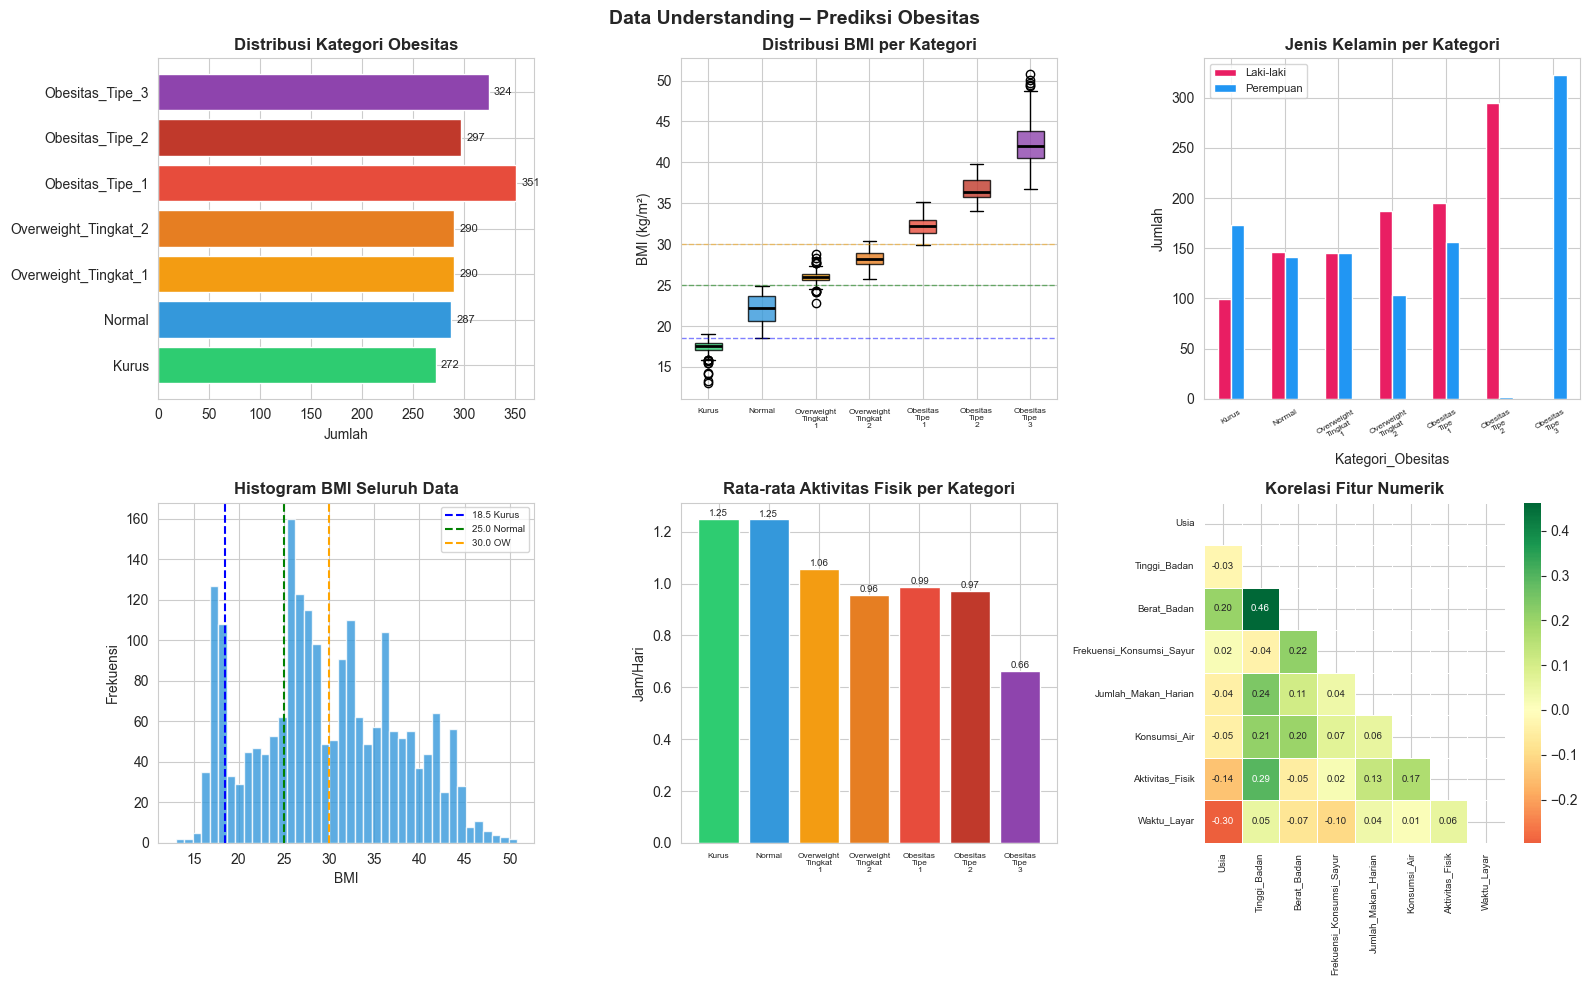


  ✅ Visualisasi disimpan: 1_data_understanding.png


In [2]:
"""
================================================================
PREDIKSI OBESITAS - STEP 1: DATA UNDERSTANDING
================================================================
Tujuan: Memahami data sebelum diolah
================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Setup ────────────────────────────────────────────────────
sns.set_style("whitegrid")
DATA_PATH = "data_obesitas_full_indonesia.xlsx"
TARGET    = "Kategori_Obesitas"
ORDER     = ['Kurus','Normal','Overweight_Tingkat_1','Overweight_Tingkat_2',
             'Obesitas_Tipe_1','Obesitas_Tipe_2','Obesitas_Tipe_3']
COLORS    = ['#2ecc71','#3498db','#f39c12','#e67e22','#e74c3c','#c0392b','#8e44ad']

# ── 1. Load Data ─────────────────────────────────────────────
df = pd.read_excel(DATA_PATH)

print("=" * 55)
print("  STEP 1: DATA UNDERSTANDING")
print("=" * 55)
print(f"\n  Total data   : {len(df):,} baris")
print(f"  Total kolom  : {df.shape[1]}")
print(f"  Missing value: {df.isnull().sum().sum()}")
print(f"  Duplikat     : {df.duplicated().sum()} baris")

# ── 2. Distribusi Target ──────────────────────────────────────
print("\n  Distribusi Kelas Target:")
print(f"  {'Kategori':<25} {'Jumlah':>8}  {'%':>6}")
print("  " + "-" * 42)
for cat in ORDER:
    n   = (df[TARGET] == cat).sum()
    pct = n / len(df) * 100
    print(f"  {cat:<25} {n:>8}  {pct:>5.1f}%")

# ── 3. Statistik Numerik ──────────────────────────────────────
num_cols = df.select_dtypes(include='number').columns.tolist()
print("\n  Statistik Fitur Numerik:")
print(df[num_cols].describe().round(2).to_string())

# ── 4. Visualisasi ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Data Understanding – Prediksi Obesitas', fontsize=14, fontweight='bold')

# Plot 1: Distribusi kelas
ax = axes[0, 0]
counts = [df[TARGET].value_counts().get(o, 0) for o in ORDER]
bars = ax.barh(ORDER, counts, color=COLORS)
for bar, val in zip(bars, counts):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=8)
ax.set_title('Distribusi Kategori Obesitas', fontweight='bold')
ax.set_xlabel('Jumlah')

# Plot 2: BMI per kelas (hitung dulu)
ax = axes[0, 1]
df['BMI_temp'] = df['Berat_Badan'] / (df['Tinggi_Badan'] ** 2)
bmi_data = [df[df[TARGET] == o]['BMI_temp'].values for o in ORDER]
bp = ax.boxplot(bmi_data, patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.8)
ax.set_xticklabels([o.replace('_', '\n') for o in ORDER], fontsize=6)
ax.set_title('Distribusi BMI per Kategori', fontweight='bold')
ax.set_ylabel('BMI (kg/m²)')
ax.axhline(18.5, color='blue',   linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(25.0, color='green',  linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(30.0, color='orange', linestyle='--', linewidth=1, alpha=0.5)

# Plot 3: Jenis kelamin per kategori
ax = axes[0, 2]
ct = pd.crosstab(df[TARGET], df['Jenis_Kelamin'])
ct = ct.reindex([o for o in ORDER if o in ct.index])
ct.plot(kind='bar', ax=ax, color=['#e91e63','#2196f3'], edgecolor='white')
ax.set_xticklabels([o.replace('_', '\n') for o in ORDER if o in ct.index], rotation=30, fontsize=6)
ax.set_title('Jenis Kelamin per Kategori', fontweight='bold')
ax.set_ylabel('Jumlah')
ax.legend(['Laki-laki','Perempuan'], fontsize=8)

# Plot 4: Histogram BMI
ax = axes[1, 0]
ax.hist(df['BMI_temp'], bins=40, color='#3498db', edgecolor='white', alpha=0.8)
ax.axvline(18.5, color='blue',   linestyle='--', linewidth=1.5, label='18.5 Kurus')
ax.axvline(25.0, color='green',  linestyle='--', linewidth=1.5, label='25.0 Normal')
ax.axvline(30.0, color='orange', linestyle='--', linewidth=1.5, label='30.0 OW')
ax.set_title('Histogram BMI Seluruh Data', fontweight='bold')
ax.set_xlabel('BMI'); ax.set_ylabel('Frekuensi')
ax.legend(fontsize=7)

# Plot 5: Aktivitas fisik per kategori
ax = axes[1, 1]
af_means = [df[df[TARGET] == o]['Aktivitas_Fisik'].mean() for o in ORDER]
bars5 = ax.bar(range(len(ORDER)), af_means, color=COLORS)
for bar, val in zip(bars5, af_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', fontsize=7)
ax.set_xticks(range(len(ORDER)))
ax.set_xticklabels([o.replace('_', '\n') for o in ORDER], fontsize=6)
ax.set_title('Rata-rata Aktivitas Fisik per Kategori', fontweight='bold')
ax.set_ylabel('Jam/Hari')

# Plot 6: Heatmap korelasi numerik
ax = axes[1, 2]
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, linewidths=0.5, annot_kws={'size': 7})
ax.set_title('Korelasi Fitur Numerik', fontweight='bold')
ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('1_data_understanding.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("\n  ✅ Visualisasi disimpan: 1_data_understanding.png")

In [3]:
"""
================================================================
PREDIKSI OBESITAS - STEP 2: DATA PREPARATION
================================================================
Tujuan: Membersihkan dan menyiapkan data untuk modeling
================================================================
"""

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = "data_obesitas_full_indonesia.xlsx"
TARGET    = "Kategori_Obesitas"
TARGET_ORDER = ['Kurus','Normal','Overweight_Tingkat_1','Overweight_Tingkat_2',
                'Obesitas_Tipe_1','Obesitas_Tipe_2','Obesitas_Tipe_3']

print("=" * 55)
print("  STEP 2: DATA PREPARATION")
print("=" * 55)

# ── 1. Load ───────────────────────────────────────────────────
df = pd.read_excel(DATA_PATH)
print(f"\n  [1] Load data: {df.shape[0]:,} baris × {df.shape[1]} kolom")

# ── 2. Hapus Duplikat ─────────────────────────────────────────
n_sebelum = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"  [2] Hapus duplikat: {n_sebelum - len(df)} baris dihapus → sisa {len(df):,}")

# ── 3. Feature Engineering ────────────────────────────────────
# Hitung BMI dari tinggi (meter) dan berat (kg)
df['BMI'] = df['Berat_Badan'] / (df['Tinggi_Badan'] ** 2)
print(f"  [3] BMI dihitung → min:{df['BMI'].min():.1f}  max:{df['BMI'].max():.1f}  mean:{df['BMI'].mean():.1f}")

# CATATAN: Kategori_BMI TIDAK dibuat karena redundan dengan BMI
#          Memasukkan keduanya = data leakage → overfitting!

# ── 4. Encoding ───────────────────────────────────────────────
print("  [4] Encoding fitur kategorik...")

df_enc = df.copy()

# Binary: Ya=1, Tidak=0 / Laki-laki=1, Perempuan=0
binary = {
    'Jenis_Kelamin'              : {'Laki-laki': 1, 'Perempuan': 0},
    'Sering_Makan_Tinggi_Kalori' : {'Ya': 1, 'Tidak': 0},
    'Monitoring_Kalori'          : {'Ya': 1, 'Tidak': 0},
    'Merokok'                    : {'Ya': 1, 'Tidak': 0},
    'Riwayat_Keluarga_Overweight': {'Ya': 1, 'Tidak': 0},
}
for col, mapping in binary.items():
    df_enc[col] = df_enc[col].map(mapping)
    print(f"       Binary  – {col}")

# Ordinal: sesuai intensitas
ordinal = {
    'Konsumsi_Alkohol' : {'Tidak': 0, 'Kadang': 1, 'Sering': 2, 'Selalu': 3},
    'Kebiasaan_Ngamil' : {'Tidak': 0, 'Kadang': 1, 'Sering': 2, 'Selalu': 3},
}
for col, mapping in ordinal.items():
    df_enc[col] = df_enc[col].map(mapping)
    print(f"       Ordinal – {col}")

# One-Hot: Transportasi (tidak ada urutan)
transport_dummies = pd.get_dummies(df_enc['Transportasi'], prefix='Transportasi')
df_enc = pd.concat([df_enc.drop('Transportasi', axis=1), transport_dummies], axis=1)
print(f"       OHE     – Transportasi → {transport_dummies.columns.tolist()}")

# Target encoding
target_map = {label: i for i, label in enumerate(TARGET_ORDER)}
df_enc['Target'] = df_enc[TARGET].map(target_map)

# ── 5. Seleksi Fitur ──────────────────────────────────────────
# PENTING: Kategori_BMI TIDAK dimasukkan (redundan dengan BMI)
FEATURE_COLS = [
    'Usia', 'Tinggi_Badan', 'Berat_Badan', 'BMI',
    'Frekuensi_Konsumsi_Sayur', 'Jumlah_Makan_Harian',
    'Konsumsi_Air', 'Aktivitas_Fisik', 'Waktu_Layar',
    'Jenis_Kelamin', 'Konsumsi_Alkohol', 'Sering_Makan_Tinggi_Kalori',
    'Monitoring_Kalori', 'Merokok', 'Riwayat_Keluarga_Overweight',
    'Kebiasaan_Ngamil',
] + transport_dummies.columns.tolist()

X = df_enc[FEATURE_COLS]
y = df_enc['Target']

print(f"\n  [5] Fitur terpilih: {len(FEATURE_COLS)} fitur")
print(f"       ⚠️  Kategori_BMI TIDAK dimasukkan (redundan dengan BMI)")

# ── 6. Train-Test Split ───────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n  [6] Train-Test Split 80:20")
print(f"       Train: {len(X_train):,} baris")
print(f"       Test : {len(X_test):,} baris")

# ── 7. Simpan ─────────────────────────────────────────────────
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv',   index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv',   index=False)

print("\n  [7] File tersimpan:")
print("       ✅ X_train.csv, X_test.csv")
print("       ✅ y_train.csv, y_test.csv")
print("\n  ✅ DATA PREPARATION SELESAI")
print("     Lanjut ke: python 3_modeling.py")

  STEP 2: DATA PREPARATION

  [1] Load data: 2,111 baris × 17 kolom
  [2] Hapus duplikat: 24 baris dihapus → sisa 2,087
  [3] BMI dihitung → min:13.0  max:50.8  mean:29.8
  [4] Encoding fitur kategorik...
       Binary  – Jenis_Kelamin
       Binary  – Sering_Makan_Tinggi_Kalori
       Binary  – Monitoring_Kalori
       Binary  – Merokok
       Binary  – Riwayat_Keluarga_Overweight
       Ordinal – Konsumsi_Alkohol
       Ordinal – Kebiasaan_Ngamil
       OHE     – Transportasi → ['Transportasi_Jalan_Kaki', 'Transportasi_Mobil', 'Transportasi_Motor', 'Transportasi_Sepeda', 'Transportasi_Transportasi_Umum']

  [5] Fitur terpilih: 21 fitur
       ⚠️  Kategori_BMI TIDAK dimasukkan (redundan dengan BMI)

  [6] Train-Test Split 80:20
       Train: 1,669 baris
       Test : 418 baris

  [7] File tersimpan:
       ✅ X_train.csv, X_test.csv
       ✅ y_train.csv, y_test.csv

  ✅ DATA PREPARATION SELESAI
     Lanjut ke: python 3_modeling.py


  STEP 3: MODELING – RANDOM FOREST

  Data train: (1669, 21)  |  Data test: (418, 21)
  Jumlah fitur: 21

  [BASELINE] Decision Tree default...
  Train: 100.00%  Test: 97.13%  Gap: 2.87%

  [RANDOM FOREST] Melatih model... ✅ Selesai!

  ┌──────────────────────────────────────────────────────┐
  │  PERBANDINGAN HASIL                                   │
  ├─────────────────────┬──────────────┬─────────────────┤
  │ Metrik              │ Dec. Tree    │ Random Forest   │
  ├─────────────────────┼──────────────┼─────────────────┤
  │ Accuracy Train      │   100.00%    │       99.76%    │
  │ Accuracy Test       │    97.13%    │       98.80%    │
  │ Gap (Overfitting)   │     2.87%    │        0.96%    │
  │ F1 Test             │      -       │      0.9880     │
  │ CV Accuracy (mean)  │      -       │  98.08% ±0.45%  │
  └─────────────────────┴──────────────┴─────────────────┘

  Status: ✅ Tidak Overfitting

  Classification Report per Kelas:

  Kategori                    F1-Score    Suppo

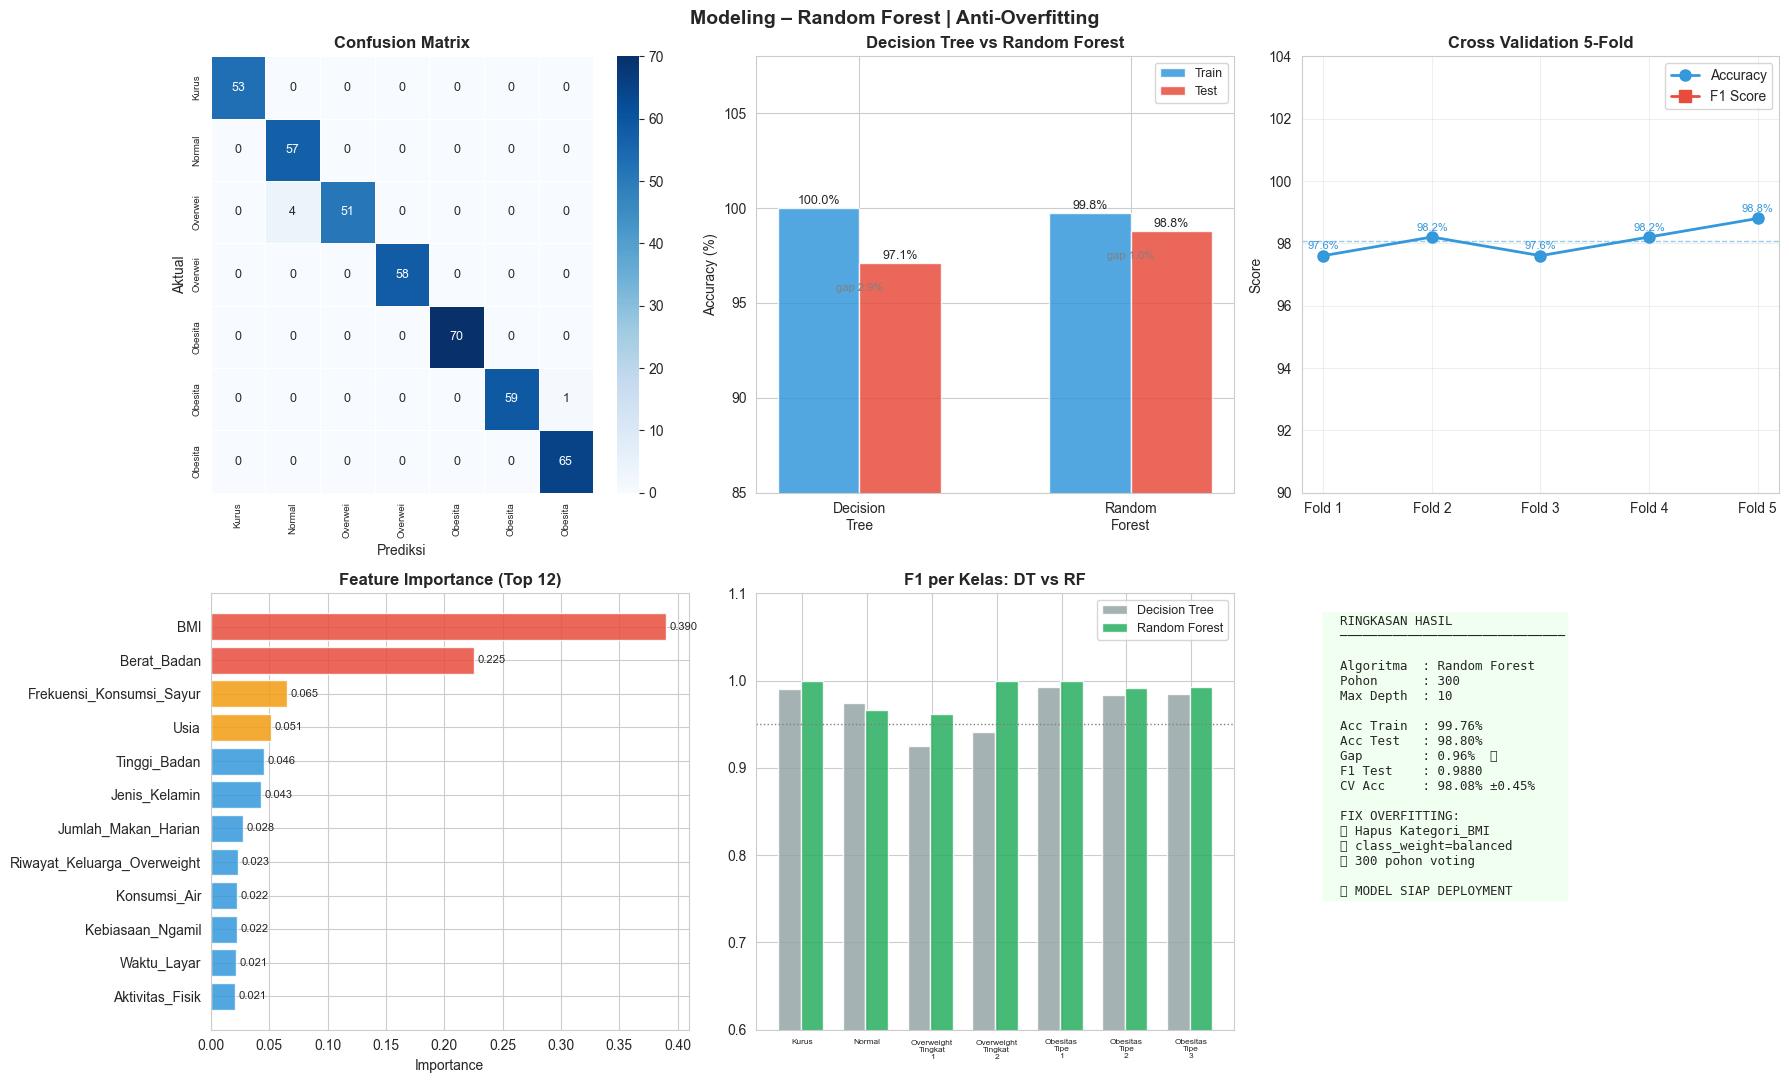

  ✅ Visualisasi disimpan: 3_modeling.png

  ✅ MODELING SELESAI
     Lanjut ke: python 4_evaluation.py


In [ ]:
"""
================================================================
PREDIKSI OBESITAS - STEP 3: MODELING
================================================================
Algoritma : Random Forest (Anti-Overfitting)
Fix       : Hapus Kategori_BMI (redundan → overfitting)
            class_weight=balanced → kelas minoritas diperhatikan
================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.model_selection import StratifiedKFold, cross_val_score

sns.set_style("whitegrid")

TARGET_NAMES = ['Kurus','Normal','Overweight_Tingkat_1','Overweight_Tingkat_2',
                'Obesitas_Tipe_1','Obesitas_Tipe_2','Obesitas_Tipe_3']
COLORS = ['#2ecc71','#3498db','#f39c12','#e67e22','#e74c3c','#c0392b','#8e44ad']

print("=" * 55)
print("  STEP 3: MODELING – RANDOM FOREST")
print("=" * 55)

# ── 1. Load Data ─────────────────────────────────────────────
X_train = pd.read_csv('X_train.csv')
X_test  = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test  = pd.read_csv('y_test.csv').squeeze()
FEATURE_NAMES = X_train.columns.tolist()

print(f"\n  Data train: {X_train.shape}  |  Data test: {X_test.shape}")
print(f"  Jumlah fitur: {len(FEATURE_NAMES)}")

# ── 2. Baseline: Decision Tree ────────────────────────────────
print("\n  [BASELINE] Decision Tree default...")
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
acc_dt_tr = accuracy_score(y_train, dt.predict(X_train))
acc_dt_te = accuracy_score(y_test,  dt.predict(X_test))
print(f"  Train: {acc_dt_tr*100:.2f}%  Test: {acc_dt_te*100:.2f}%  Gap: {(acc_dt_tr-acc_dt_te)*100:.2f}%")

# ── 3. Random Forest ──────────────────────────────────────────
print("\n  [RANDOM FOREST] Melatih model... ", end='', flush=True)

rf = RandomForestClassifier(
    n_estimators   = 100,        # 100 pohon voting bersama
    max_depth      = None,         # max kedalaman tiap pohon
    min_samples_split = 10,      # min sampel untuk split
    min_samples_leaf  = 4,       # min sampel di daun
    max_features   = 'sqrt',     # fitur random per split
    class_weight   = 'balanced', # perhatikan kelas minoritas
    random_state   = 42,
    n_jobs         = -1
)
rf.fit(X_train, y_train)
print("✅ Selesai!")

# ── 4. Evaluasi ───────────────────────────────────────────────
y_pred_tr = rf.predict(X_train)
y_pred_te = rf.predict(X_test)

acc_tr = accuracy_score(y_train, y_pred_tr)
acc_te = accuracy_score(y_test,  y_pred_te)
f1_te  = f1_score(y_test, y_pred_te, average='weighted')
gap    = acc_tr - acc_te

skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc = cross_val_score(rf, X_train, y_train, cv=skf, scoring='accuracy')
cv_f1  = cross_val_score(rf, X_train, y_train, cv=skf, scoring='f1_weighted')

print(f"""
  ┌──────────────────────────────────────────────────────┐
  │  PERBANDINGAN HASIL                                   │
  ├─────────────────────┬──────────────┬─────────────────┤
  │ Metrik              │ Dec. Tree    │ Random Forest   │
  ├─────────────────────┼──────────────┼─────────────────┤
  │ Accuracy Train      │ {acc_dt_tr*100:>8.2f}%    │ {acc_tr*100:>11.2f}%    │
  │ Accuracy Test       │ {acc_dt_te*100:>8.2f}%    │ {acc_te*100:>11.2f}%    │
  │ Gap (Overfitting)   │ {(acc_dt_tr-acc_dt_te)*100:>8.2f}%    │ {gap*100:>11.2f}%    │
  │ F1 Test             │      -       │ {f1_te:>11.4f}     │
  │ CV Accuracy (mean)  │      -       │ {cv_acc.mean()*100:>6.2f}% ±{cv_acc.std()*100:.2f}%  │
  └─────────────────────┴──────────────┴─────────────────┘

  Status: {'✅ Tidak Overfitting' if gap < 0.05 else '⚠️ Sedikit Overfitting' if gap < 0.10 else '❌ Overfitting'}
""")

# ── 5. Classification Report ──────────────────────────────────
print("  Classification Report per Kelas:")
rep = classification_report(y_test, y_pred_te, target_names=TARGET_NAMES, output_dict=True)
print(f"\n  {'Kategori':<25} {'F1-Score':>10} {'Support':>10}")
print("  " + "─" * 50)
for cat in TARGET_NAMES:
    r    = rep[cat]
    flag = "✅" if r['f1-score'] >= 0.95 else "⚠️ " if r['f1-score'] >= 0.90 else "❌"
    print(f"  {cat:<25} {r['f1-score']:>10.4f} {int(r['support']):>10}  {flag}")

# ── 6. Feature Importance ─────────────────────────────────────
fi = pd.Series(rf.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)
print(f"\n  Top 10 Feature Importance:")
for feat, imp in fi.head(10).items():
    bar = "█" * int(imp * 50)
    print(f"  {feat:<35} {imp:.4f}  {bar}")

# ── 7. Simpan Model ───────────────────────────────────────────
with open('decision_tree_model.pkl', 'wb') as f:
    pickle.dump({
        'model'       : rf,
        'features'    : FEATURE_NAMES,
        'target_names': TARGET_NAMES,
        'metrics': {
            'acc_train': acc_tr, 'acc_test': acc_te,
            'f1_test'  : f1_te,  'gap'     : gap,
            'cv_acc'   : cv_acc.mean(), 'cv_f1': cv_f1.mean(),
        }
    }, f)
print("\n  ✅ Model disimpan: decision_tree_model.pkl")

# ── 8. Visualisasi ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Modeling – Random Forest | Anti-Overfitting', fontsize=14, fontweight='bold')

# Plot 1: Confusion Matrix
ax = axes[0, 0]
cm = confusion_matrix(y_test, y_pred_te)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=[t[:7] for t in TARGET_NAMES],
            yticklabels=[t[:7] for t in TARGET_NAMES],
            linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Confusion Matrix', fontweight='bold')
ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
ax.tick_params(labelsize=7)

# Plot 2: DT vs RF
ax = axes[0, 1]
x = np.arange(2)
w = 0.3
tr_vals = [acc_dt_tr*100, acc_tr*100]
te_vals = [acc_dt_te*100, acc_te*100]
ax.bar(x - w/2, tr_vals, w, label='Train', color='#3498db', alpha=0.85)
ax.bar(x + w/2, te_vals, w, label='Test',  color='#e74c3c', alpha=0.85)
for i, (tr, te) in enumerate(zip(tr_vals, te_vals)):
    ax.text(i - w/2, tr + 0.2, f'{tr:.1f}%', ha='center', fontsize=9)
    ax.text(i + w/2, te + 0.2, f'{te:.1f}%', ha='center', fontsize=9)
    ax.text(i, min(tr,te)-1.5, f'gap {abs(tr-te):.1f}%', ha='center', fontsize=8, color='gray')
ax.set_xticks(x); ax.set_xticklabels(['Decision\nTree', 'Random\nForest'])
ax.set_ylim(85, 108); ax.set_title('Decision Tree vs Random Forest', fontweight='bold')
ax.set_ylabel('Accuracy (%)'); ax.legend(fontsize=9)

# Plot 3: Cross Validation
ax = axes[0, 2]
folds = [f'Fold {i+1}' for i in range(5)]
ax.plot(folds, cv_acc*100, 'o-', color='#3498db', linewidth=2, markersize=8, label='Accuracy')
ax.plot(folds, cv_f1,      's-', color='#e74c3c', linewidth=2, markersize=8, label='F1 Score')
for i, a in enumerate(cv_acc):
    ax.text(i, a*100+0.2, f'{a*100:.1f}%', ha='center', fontsize=8, color='#3498db')
ax.axhline(cv_acc.mean()*100, color='#3498db', linestyle='--', linewidth=1, alpha=0.5)
ax.set_ylim(90, 104); ax.set_title('Cross Validation 5-Fold', fontweight='bold')
ax.set_ylabel('Score'); ax.legend(); ax.grid(alpha=0.3)

# Plot 4: Feature Importance
ax = axes[1, 0]
fi_top = fi.head(12)
colors4 = ['#e74c3c' if v > 0.1 else '#f39c12' if v > 0.05 else '#3498db' for v in fi_top.values]
bars4 = ax.barh(fi_top.index[::-1], fi_top.values[::-1], color=colors4[::-1], alpha=0.85)
for bar, val in zip(bars4, fi_top.values[::-1]):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=8)
ax.set_title('Feature Importance (Top 12)', fontweight='bold'); ax.set_xlabel('Importance')

# Plot 5: F1 per Kelas DT vs RF
ax = axes[1, 1]
dt_rep = classification_report(y_test, dt.predict(X_test), target_names=TARGET_NAMES, output_dict=True)
f1_dt  = [dt_rep[c]['f1-score'] for c in TARGET_NAMES]
f1_rf  = [rep[c]['f1-score']    for c in TARGET_NAMES]
x5 = np.arange(len(TARGET_NAMES))
ax.bar(x5-0.2, f1_dt, 0.35, label='Decision Tree', color='#95a5a6', alpha=0.85)
ax.bar(x5+0.15, f1_rf, 0.35, label='Random Forest', color='#27ae60', alpha=0.85)
ax.set_xticks(x5); ax.set_xticklabels([t.replace('_','\n') for t in TARGET_NAMES], fontsize=6)
ax.set_ylim(0.6, 1.1); ax.axhline(0.95, color='gray', linestyle=':', linewidth=1)
ax.set_title('F1 per Kelas: DT vs RF', fontweight='bold'); ax.legend(fontsize=9)

# Plot 6: Ringkasan
ax = axes[1, 2]; ax.axis('off')
txt = (
    "  RINGKASAN HASIL\n"
    "  " + "─"*30 + "\n\n"
    "  Algoritma  : Random Forest\n"
    "  Pohon      : 300\n"
    "  Max Depth  : 10\n\n"
    f"  Acc Train  : {acc_tr*100:.2f}%\n"
    f"  Acc Test   : {acc_te*100:.2f}%\n"
    f"  Gap        : {gap*100:.2f}%  ✅\n"
    f"  F1 Test    : {f1_te:.4f}\n"
    f"  CV Acc     : {cv_acc.mean()*100:.2f}% ±{cv_acc.std()*100:.2f}%\n\n"
    "  FIX OVERFITTING:\n"
    "  ✅ Hapus Kategori_BMI\n"
    "  ✅ class_weight=balanced\n"
    "  ✅ 300 pohon voting\n\n"
    "  ✅ MODEL SIAP DEPLOYMENT"
)
ax.text(0.05, 0.95, txt, transform=ax.transAxes, fontsize=9,
        va='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#f0fff0', alpha=0.9))

plt.tight_layout()
plt.savefig('3_modeling.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("  ✅ Visualisasi disimpan: 3_modeling.png")
print("\n  ✅ MODELING SELESAI")
print("     Lanjut ke: python 4_evaluation.py")

  STEP 4: EVALUATION

  Metrik Evaluasi:
  ─────────────────────────────────────
  Accuracy Train      : 99.76%
  Accuracy Test       : 98.80%
  Gap (Overfitting)   : 0.96%  ✅
  Precision           : 0.9887
  Recall              : 0.9880
  F1-Score            : 0.9880

  Classification Report:
  Kategori                   Precision     Recall         F1   Support
  ────────────────────────────────────────────────────────────────────
  Kurus                         1.0000     1.0000     1.0000        53  ✅
  Normal                        0.9344     1.0000     0.9661        57  ✅
  Overweight_Tingkat_1          1.0000     0.9273     0.9623        55  ✅
  Overweight_Tingkat_2          1.0000     1.0000     1.0000        58  ✅
  Obesitas_Tipe_1               1.0000     1.0000     1.0000        70  ✅
  Obesitas_Tipe_2               1.0000     0.9833     0.9916        60  ✅
  Obesitas_Tipe_3               0.9848     1.0000     0.9924        65  ✅

  Cross Validation (5-Fold):
  CV Accuracy :

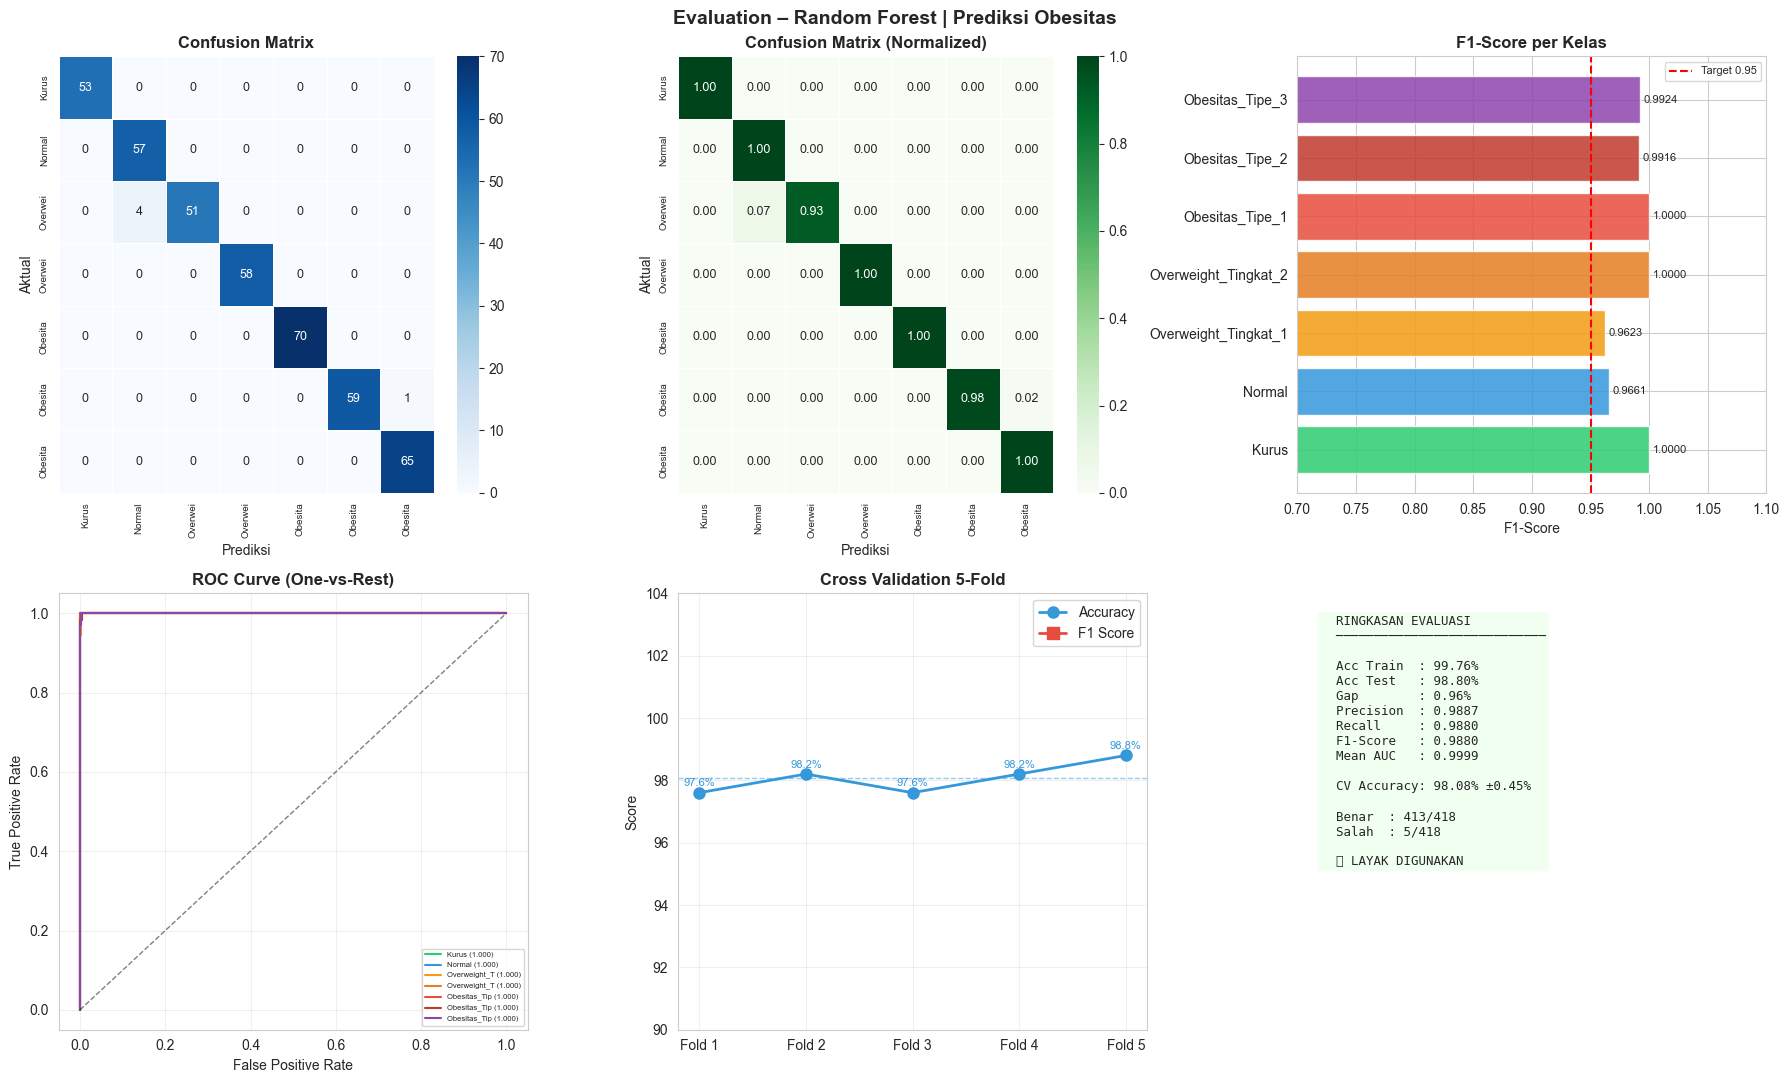


  ✅ Visualisasi disimpan: 4_evaluation.png

  ✅ EVALUATION SELESAI
     Model siap digunakan!


In [10]:
"""
================================================================
PREDIKSI OBESITAS - STEP 4: EVALUATION
================================================================
Tujuan: Mengukur seberapa baik model bekerja
================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (accuracy_score, precision_score,
    recall_score, f1_score, classification_report,
    confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import StratifiedKFold, cross_val_score

sns.set_style("whitegrid")
TARGET_NAMES = ['Kurus','Normal','Overweight_Tingkat_1','Overweight_Tingkat_2',
                'Obesitas_Tipe_1','Obesitas_Tipe_2','Obesitas_Tipe_3']
COLORS = ['#2ecc71','#3498db','#f39c12','#e67e22','#e74c3c','#c0392b','#8e44ad']

print("=" * 55)
print("  STEP 4: EVALUATION")
print("=" * 55)

# ── Load ──────────────────────────────────────────────────────
X_train = pd.read_csv('X_train.csv')
X_test  = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test  = pd.read_csv('y_test.csv').squeeze()

with open('decision_tree_model.pkl', 'rb') as f:
    data = pickle.load(f)
model = data['model']

y_pred  = model.predict(X_test)
y_prob  = model.predict_proba(X_test)
y_pred_tr = model.predict(X_train)

# ── Metrik Utama ──────────────────────────────────────────────
acc_tr  = accuracy_score(y_train, y_pred_tr)
acc_te  = accuracy_score(y_test,  y_pred)
prec    = precision_score(y_test, y_pred, average='weighted')
rec     = recall_score(y_test,    y_pred, average='weighted')
f1      = f1_score(y_test,        y_pred, average='weighted')
gap     = acc_tr - acc_te

print(f"""
  Metrik Evaluasi:
  ─────────────────────────────────────
  Accuracy Train      : {acc_tr*100:.2f}%
  Accuracy Test       : {acc_te*100:.2f}%
  Gap (Overfitting)   : {gap*100:.2f}%  {'✅' if gap < 0.05 else '⚠️'}
  Precision           : {prec:.4f}
  Recall              : {rec:.4f}
  F1-Score            : {f1:.4f}
""")

# ── Classification Report ─────────────────────────────────────
rep = classification_report(y_test, y_pred, target_names=TARGET_NAMES, output_dict=True)
print("  Classification Report:")
print(f"  {'Kategori':<25} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>9}")
print("  " + "─" * 68)
for cat in TARGET_NAMES:
    r    = rep[cat]
    flag = "✅" if r['f1-score'] >= 0.95 else "⚠️ " if r['f1-score'] >= 0.90 else "❌"
    print(f"  {cat:<25} {r['precision']:>10.4f} {r['recall']:>10.4f} {r['f1-score']:>10.4f} {int(r['support']):>9}  {flag}")

# ── Cross Validation ──────────────────────────────────────────
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
cv_f1  = cross_val_score(model, X_train, y_train, cv=skf, scoring='f1_weighted')

print(f"\n  Cross Validation (5-Fold):")
print(f"  CV Accuracy : {cv_acc.mean()*100:.2f}% ± {cv_acc.std()*100:.2f}%")
print(f"  CV F1-Score : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print(f"  Stabilitas  : {'✅ Stabil' if cv_acc.std() < 0.02 else '⚠️ Cukup Stabil'}")

# ── AUC ───────────────────────────────────────────────────────
y_bin  = label_binarize(y_test, classes=list(range(7)))
aucs   = {}
for i, cat in enumerate(TARGET_NAMES):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    aucs[cat]   = auc(fpr, tpr)

mean_auc = np.mean(list(aucs.values()))
print(f"\n  AUC per Kelas:")
for cat, val in aucs.items():
    flag = "✅" if val >= 0.99 else "⚠️"
    print(f"  {cat:<30} {val:.4f}  {flag}")
print(f"  Mean AUC: {mean_auc:.4f}")

# ── Analisis Kesalahan ────────────────────────────────────────
wrong   = np.where(y_pred != y_test)[0]
correct = len(y_test) - len(wrong)
print(f"\n  Prediksi benar: {correct} ({correct/len(y_test)*100:.2f}%)")
print(f"  Prediksi salah: {len(wrong)} ({len(wrong)/len(y_test)*100:.2f}%)")

if len(wrong) > 0:
    err = {}
    for idx in wrong:
        k = (TARGET_NAMES[y_test.iloc[idx]], TARGET_NAMES[y_pred[idx]])
        err[k] = err.get(k, 0) + 1
    print(f"\n  Pola Kesalahan Terbanyak:")
    for (act, pred), cnt in sorted(err.items(), key=lambda x: -x[1])[:5]:
        print(f"  {act:<28} → {pred:<28} ({cnt}x)")

# ── Visualisasi ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Evaluation – Random Forest | Prediksi Obesitas', fontsize=14, fontweight='bold')

# Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=[t[:7] for t in TARGET_NAMES],
            yticklabels=[t[:7] for t in TARGET_NAMES],
            linewidths=0.5, annot_kws={'size': 9})
axes[0,0].set_title('Confusion Matrix', fontweight='bold')
axes[0,0].set_xlabel('Prediksi'); axes[0,0].set_ylabel('Aktual')
axes[0,0].tick_params(labelsize=7)

# Plot 2: Confusion Matrix Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', ax=axes[0,1],
            xticklabels=[t[:7] for t in TARGET_NAMES],
            yticklabels=[t[:7] for t in TARGET_NAMES],
            linewidths=0.5, annot_kws={'size': 9}, vmin=0, vmax=1)
axes[0,1].set_title('Confusion Matrix (Normalized)', fontweight='bold')
axes[0,1].set_xlabel('Prediksi'); axes[0,1].set_ylabel('Aktual')
axes[0,1].tick_params(labelsize=7)

# Plot 3: F1 per Kelas
ax = axes[0,2]
f1_vals = [rep[c]['f1-score'] for c in TARGET_NAMES]
bars = ax.barh(TARGET_NAMES, f1_vals, color=COLORS, alpha=0.85)
for bar, val in zip(bars, f1_vals):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=8)
ax.axvline(0.95, color='red', linestyle='--', linewidth=1.5, label='Target 0.95')
ax.set_xlim(0.7, 1.1); ax.set_title('F1-Score per Kelas', fontweight='bold')
ax.set_xlabel('F1-Score'); ax.legend(fontsize=8)

# Plot 4: ROC Curve
ax = axes[1,0]
for i, (cat, color) in enumerate(zip(TARGET_NAMES, COLORS)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    ax.plot(fpr, tpr, color=color, linewidth=1.5, label=f'{cat[:12]} ({aucs[cat]:.3f})')
ax.plot([0,1],[0,1],'k--', linewidth=1, alpha=0.5)
ax.set_title('ROC Curve (One-vs-Rest)', fontweight='bold')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=5.5, loc='lower right'); ax.grid(alpha=0.3)

# Plot 5: CV per Fold
ax = axes[1,1]
folds = [f'Fold {i+1}' for i in range(5)]
ax.plot(folds, cv_acc*100, 'o-', color='#3498db', linewidth=2, markersize=8, label='Accuracy')
ax.plot(folds, cv_f1,      's-', color='#e74c3c', linewidth=2, markersize=8, label='F1 Score')
for i, a in enumerate(cv_acc):
    ax.text(i, a*100+0.2, f'{a*100:.1f}%', ha='center', fontsize=8, color='#3498db')
ax.axhline(cv_acc.mean()*100, color='#3498db', linestyle='--', linewidth=1, alpha=0.5)
ax.set_ylim(90, 104); ax.set_title('Cross Validation 5-Fold', fontweight='bold')
ax.set_ylabel('Score'); ax.legend(); ax.grid(alpha=0.3)

# Plot 6: Ringkasan
ax = axes[1,2]; ax.axis('off')
txt = (
    "  RINGKASAN EVALUASI\n"
    "  " + "─"*28 + "\n\n"
    f"  Acc Train  : {acc_tr*100:.2f}%\n"
    f"  Acc Test   : {acc_te*100:.2f}%\n"
    f"  Gap        : {gap*100:.2f}%\n"
    f"  Precision  : {prec:.4f}\n"
    f"  Recall     : {rec:.4f}\n"
    f"  F1-Score   : {f1:.4f}\n"
    f"  Mean AUC   : {mean_auc:.4f}\n\n"
    f"  CV Accuracy: {cv_acc.mean()*100:.2f}% ±{cv_acc.std()*100:.2f}%\n\n"
    f"  Benar  : {correct}/{len(y_test)}\n"
    f"  Salah  : {len(wrong)}/{len(y_test)}\n\n"
    f"  {'✅ LAYAK DIGUNAKAN' if acc_te >= 0.95 else '⚠️ PERLU PERBAIKAN'}"
)
ax.text(0.05, 0.95, txt, transform=ax.transAxes, fontsize=9,
        va='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#f0fff0', alpha=0.9))

plt.tight_layout()
plt.savefig('4_evaluation.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("\n  ✅ Visualisasi disimpan: 4_evaluation.png")
print("\n  ✅ EVALUATION SELESAI")
print("     Model siap digunakan!")